In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
history_path = Path("../logs/train_history.json")
with open(history_path) as f:
    history = json.load(f)

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
train_f1 = [h["train_f1"] for h in history]
val_f1 = [h["val_f1"] for h in history]
lr = [h["lr"] for h in history]

best_epoch = int(np.argmax(val_f1)) + 1
best_val_f1 = max(val_f1)
print(f"Best epoch: {best_epoch}")
print(f"Best val F1: {best_val_f1:.4f}")

Best epoch: 10
Best val F1: 0.7084


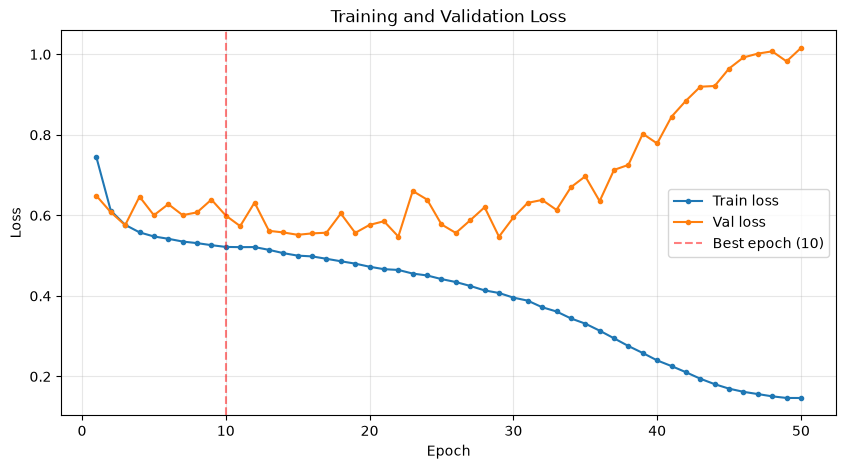

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, label="Train loss", marker="o", markersize=3)
ax.plot(epochs, val_loss, label="Val loss", marker="o", markersize=3)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.5,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

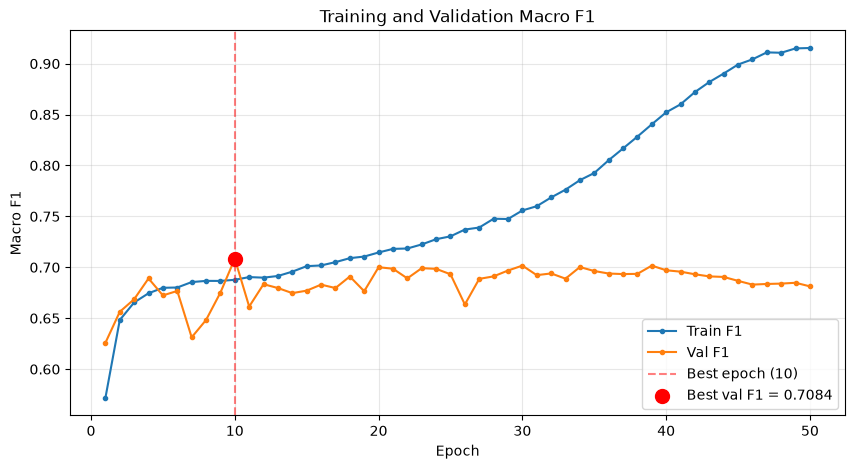

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_f1, label="Train F1", marker="o", markersize=3)
ax.plot(epochs, val_f1, label="Val F1", marker="o", markersize=3)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.5,
           label=f"Best epoch ({best_epoch})")
ax.scatter([best_epoch], [best_val_f1], color="red", s=100, zorder=5,
           label=f"Best val F1 = {best_val_f1:.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.set_title("Training and Validation Macro F1")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [5]:
final_gap = train_f1[-1] - val_f1[-1]
print(f"Final train F1: {train_f1[-1]:.4f}")
print(f"Final val F1:   {val_f1[-1]:.4f}")
print(f"Gap (overfitting): {final_gap:.4f}")
print()
print("Interpretation:")
print("- Small gap (<0.05) = underfit or well-regularized")
print("- Medium gap (0.05-0.15) = mild overfitting")
print("- Large gap (>0.15) = severe overfitting")

Final train F1: 0.9154
Final val F1:   0.6813
Gap (overfitting): 0.2341

Interpretation:
- Small gap (<0.05) = underfit or well-regularized
- Medium gap (0.05-0.15) = mild overfitting
- Large gap (>0.15) = severe overfitting


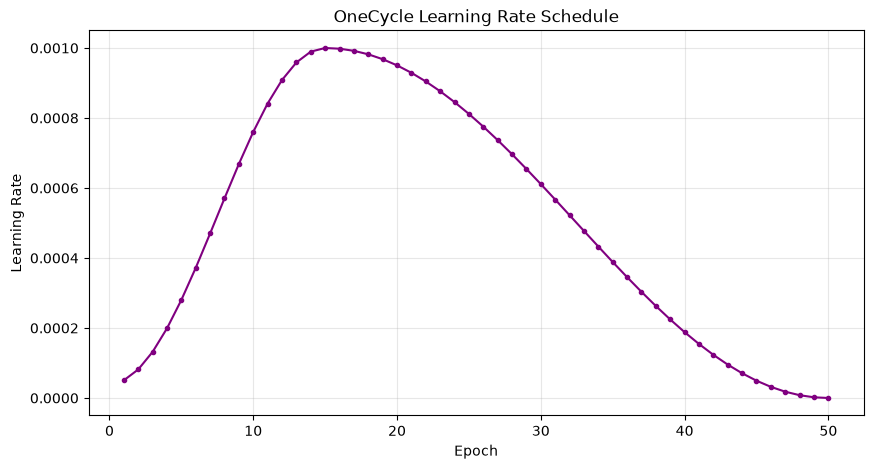

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, lr, marker="o", markersize=3, color="purple")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("OneCycle Learning Rate Schedule")
ax.grid(alpha=0.3)
plt.show()

## Overfitting Analysis

**Final gap: 0.2341 → severe overfitting**

The model memorized the training set (train F1 = 0.92) while failing to generalize (val F1 = 0.68).

### Three factors contributing

1. **Model capacity vs data size**: 3.86M parameters for 15,673 training samples (~250 params/sample). Large models can memorize.
2. **Early stopping was correct**: Best val F1 was 0.7084 at epoch 10. Training to 50 epochs confirmed that more epochs hurt, not help.
3. **Class imbalance amplifies the effect**: MI and HYP have the lowest F1 (0.55, 0.49) due to fewer positive examples.

### What would fix it (future work)

- Stronger regularization: dropout 0.5, weight decay 1e-3
- Smaller model: base_channels=32 (half the capacity)
- More aggressive augmentation: higher noise, wider scaling
- Threshold tuning: lower threshold for imbalanced classes (0.3 instead of 0.5)
- Focal loss: down-weights easy examples, focuses on hard ones
- Ensemble: train 3 models with different seeds, average predictions

### Decision

Stopped at 0.69 macro F1 and moved to deployment. The deployment story (ONNX, INT8, edge, C++, full-stack) is the differentiator, not marginal gains in F1.